# Phase 2: Analysis


## Data Set Up
Combining data, basic data cleaning, and loading data.

In [2]:
# Needed setup/imports
import pandas as pd
import json
import os
import re
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load and combine all user data
base_path = "data"

all_history = []
all_playlists = []
all_library_tracks = []

for user_folder in os.listdir(base_path):
    user_path = os.path.join(base_path, user_folder)
    
    if not os.path.isdir(user_path):
        continue

    # Streaming data
    stream_files = glob(os.path.join(user_path, "StreamingHistory_music_*.json"))
    user_history = []

    for file in stream_files:
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)
            user_history.extend(data)

    if user_history:
        df_hist = pd.DataFrame(user_history)
        df_hist["user_id"] = user_folder
        all_history.append(df_hist)

    # Playlist data
    playlist_files = glob(os.path.join(user_path, "Playlist*.json"))
    playlist_tracks = []

    for file in playlist_files:
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)

        playlists = data.get("playlists", data)

        for pl in playlists:
            items = pl.get("items", [])

            for item in items:
                track = item.get("track")

                # Handle missing tracks
                if not track or not isinstance(track, dict):
                    continue

                playlist_tracks.append({
                    "artistName": track.get("artistName"),
                    "trackName": track.get("trackName"),
                    "playlistName": pl.get("name"),
                    "user_id": user_folder
                })

    if playlist_tracks:
        df_pl = pd.DataFrame(playlist_tracks)
        all_playlists.append(df_pl)

    # Library data
    lib_path = os.path.join(user_path, "YourLibrary.json")

    if os.path.exists(lib_path):
        with open(lib_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        tracks = data.get("tracks", [])

        for t in tracks:
            all_library_tracks.append({
                "artistName": t.get("artist"),
                "trackName": t.get("track"),
                "user_id": user_folder
            })

# Combine all users data
if all_history:
    history_all = pd.concat(all_history, ignore_index=True)
else:
    raise ValueError("No streaming data found.")

if all_playlists:
    playlist_all = pd.concat(all_playlists, ignore_index=True)
else:
    playlist_all = pd.DataFrame(columns=["artistName", "trackName", "user_id"])

if all_library_tracks:
    library_tracks = pd.DataFrame(all_library_tracks)
else:
    library_tracks = pd.DataFrame(columns=["artistName", "trackName", "user_id"])

print("Streaming shape:", history_all.shape)
print("Playlist shape:", playlist_all.shape)
print("Library shape:", library_tracks.shape)

Streaming shape: (205849, 5)
Playlist shape: (18368, 4)
Library shape: (6851, 3)


### Data preprocessing
Clean and standardize text, preprocessing/feature engineering for analysis

#### Cleaning and Matching

In [4]:
# Cleaning and standardizing text
def clean_text(text):
    if pd.isna(text):
        return None
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^a-z0-9 ]", "", text)
    return text

# Applying cleaning
history_all["artist_clean"] = history_all["artistName"].apply(clean_text)
history_all["track_clean"] = history_all["trackName"].apply(clean_text)

playlist_all["artist_clean"] = playlist_all["artistName"].apply(clean_text)
playlist_all["track_clean"] = playlist_all["trackName"].apply(clean_text)

library_tracks["artist_clean"] = library_tracks["artistName"].apply(clean_text)
library_tracks["track_clean"] = library_tracks["trackName"].apply(clean_text)

# Create match keys
def create_match_key(df):
    return df["artist_clean"].fillna("") + "_" + df["track_clean"].fillna("")

history_all["match_key"] = create_match_key(history_all)
playlist_all["match_key"] = create_match_key(playlist_all)
library_tracks["match_key"] = create_match_key(library_tracks)

# Precompute sets of playlist and library keys for each user for faster lookup
playlist_keys = playlist_all.groupby("user_id")["match_key"].apply(set).to_dict()
library_keys = library_tracks.groupby("user_id")["match_key"].apply(set).to_dict()

# Time preprocessing
history_all["endTime"] = pd.to_datetime(history_all["endTime"])
history_all["hour"] = history_all["endTime"].dt.hour
history_all["day_of_week"] = history_all["endTime"].dt.day_name()
history_all["month"] = history_all["endTime"].dt.month

# Determine curation level
history_all["in_playlist"] = history_all.apply(
    lambda row: row["match_key"] in playlist_keys.get(row["user_id"], set()),
    axis=1)

history_all["in_library"] = history_all.apply(
    lambda row: row["match_key"] in library_keys.get(row["user_id"], set()),
    axis=1)

history_all["curation_level"] = (
    history_all["in_playlist"].astype(int) * 2 +
    history_all["in_library"].astype(int))

labels = {
    0: "not_curated",
    1: "library",
    2: "playlist",
    3: "both"}

history_all["curation_label"] = history_all["curation_level"].map(labels)

#### Aggregation and Preprocessing

In [5]:
# Aggregate by track and user
track_summary = (
    history_all
    .groupby(["user_id", "match_key"])
    .agg({
        "msPlayed": "sum",
        "trackName": "first",
        "artistName": "first",
        "curation_level": "max",
        "curation_label": "first",
        "hour": "mean"
    })
    .reset_index()
)

# Convert to minutes
track_summary["minutes_played"] = track_summary["msPlayed"] / 60000

# Adding playcount as metric
play_counts = (
    history_all
    .groupby(["user_id", "match_key"])
    .size()
    .reset_index(name="play_count")
)

track_summary = track_summary.merge(
    play_counts,
    on=["user_id", "match_key"],
    how="left"
)

# Load and prepare track metadata
track_meta = pd.read_csv("data/track_data.csv")

track_meta["artist_clean"] = track_meta["artists"].apply(clean_text)
track_meta["track_clean"] = track_meta["track_name"].apply(clean_text)

track_meta["match_key"] = track_meta["artist_clean"] + "_" + track_meta["track_clean"]

full_data = pd.merge(
    track_summary,
    track_meta,
    on="match_key",
    how="left"
)

print("Final dataset shape:", full_data.shape)

Final dataset shape: (48676, 34)


## Research Question 1: How does user engagement with curated vs non-curated content vary by time of day and day of week?


### Time zone
Adjust timezone and execute some feature engineering for time.

In [6]:
# Fix timezone handling and create event-level time features

# Parse Spotify timestamps as UTC first
history_all["endTime_utc"] = pd.to_datetime(history_all["endTime"], utc=True, errors="coerce")

# Convert to Eastern Time
history_all["endTime_est"] = history_all["endTime_utc"].dt.tz_convert("America/New_York")

# Create time features from EST timestamps
history_all["hour_est"] = history_all["endTime_est"].dt.hour
history_all["day_of_week_est"] = history_all["endTime_est"].dt.day_name()
history_all["day_num_est"] = history_all["endTime_est"].dt.dayofweek   # Monday=0
history_all["month_est"] = history_all["endTime_est"].dt.month
history_all["date_est"] = history_all["endTime_est"].dt.date

print("Missing EST timestamps:", history_all["endTime_est"].isna().sum())

print("\nPreview of converted timestamps:")
display(
    history_all[
        ["user_id", "endTime", "endTime_utc", "endTime_est", "hour_est", "day_of_week_est"]
    ].head())

# Check the hour distribution after conversion
print("Unique days of week:")
print(history_all["day_of_week_est"].value_counts())

print("\nHour distribution preview:")
print(history_all["hour_est"].value_counts().sort_index().head(10))

Missing EST timestamps: 0

Preview of converted timestamps:


,user_id,endTime,endTime_utc,endTime_est,hour_est,day_of_week_est
0,user_5,2025-02-20 22:54:00,2025-02-20 22:54:00+00:00,2025-02-20 17:54:00-05:00,17,Thursday
1,user_5,2025-02-20 22:58:00,2025-02-20 22:58:00+00:00,2025-02-20 17:58:00-05:00,17,Thursday
2,user_5,2025-02-20 23:02:00,2025-02-20 23:02:00+00:00,2025-02-20 18:02:00-05:00,18,Thursday
3,user_5,2025-02-20 23:05:00,2025-02-20 23:05:00+00:00,2025-02-20 18:05:00-05:00,18,Thursday
4,user_5,2025-02-20 23:08:00,2025-02-20 23:08:00+00:00,2025-02-20 18:08:00-05:00,18,Thursday


Unique days of week:
day_of_week_est
Wednesday    33138
Tuesday      32296
Friday       32148
Monday       32009
Thursday     31226
Saturday     22622
Sunday       22410
Name: count, dtype: int64

Hour distribution preview:
hour_est
0    6187
1    4333
2    2743
3    1709
4    1053
5     835
6     842
7    2466
8    2810
9    4491
Name: count, dtype: int64


### Curation levels
Curation levels are set based on engagement: not_curated (no engagement outside of streaming), library (low engagement for saving to library - pressing heart button), playlist (moderate engagement of creating playlists and adding to specific playlists), both (high engagement - highest level of curation behavior of saving and adding to playlists).

In [7]:
# Confirm the 4-level curation structure

print("Curation label counts:")
print(history_all["curation_label"].value_counts(dropna=False))

# Set an explicit order for plots/tables later
curation_order = ["not_curated", "library", "playlist", "both"]

history_all["curation_label"] = pd.Categorical(
    history_all["curation_label"],
    categories=curation_order,
    ordered=True
)

print("\nOrdered curation labels:")
print(history_all["curation_label"].cat.categories)

Curation label counts:
curation_label
playlist       83788
not_curated    66015
library        33301
both           22745
Name: count, dtype: int64

Ordered curation labels:
Index(['not_curated', 'library', 'playlist', 'both'], dtype='object')


### Feature Engineering

In [8]:
# reate engagement measures at the event level

history_all["minutes_played"] = history_all["msPlayed"] / 60000

# Quick sanity check
print("Total streaming events:", len(history_all))
print("Total minutes played:", round(history_all["minutes_played"].sum(), 2))

print("\nMinutes played summary:")
print(history_all["minutes_played"].describe())

Total streaming events: 205849
Total minutes played: 349359.31

Minutes played summary:
count    205849.000000
mean          1.697163
std           1.767730
min           0.000000
25%           0.028250
50%           1.190800
75%           3.222433
max         165.283700
Name: minutes_played, dtype: float64


### Summary tables
Summary tables of engagement by temporal data.

In [ ]:
# Engagement by hour of day and curation label

hour_curation_summary = (
    history_all
    .groupby(["hour_est", "curation_label"], observed=False)
    .agg(
        stream_count=("match_key", "size"),
        total_minutes=("minutes_played", "sum")
    )
    .reset_index()
)

display(hour_curation_summary.head(20))

# Share of engagement within each hour

hour_curation_summary["stream_share_within_hour"] = (
    hour_curation_summary["stream_count"] /
    hour_curation_summary.groupby("hour_est")["stream_count"].transform("sum")
)

hour_curation_summary["minutes_share_within_hour"] = (
    hour_curation_summary["total_minutes"] /
    hour_curation_summary.groupby("hour_est")["total_minutes"].transform("sum")
)

display(hour_curation_summary.head(20))

,hour_est,curation_label,stream_count,total_minutes
0,0,not_curated,1944,3141.247400
1,0,library,1034,1929.598817
2,0,playlist,2396,4088.611267
3,0,both,813,1258.916517
4,1,not_curated,1363,2332.590133
5,1,library,718,1303.810617
6,1,playlist,1821,2717.387150
7,1,both,431,860.864833
8,2,not_curated,846,1658.258567
9,2,library,386,767.917150


In [ ]:
# Engagement by day of week and curation label

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

history_all["day_of_week_est"] = pd.Categorical(
    history_all["day_of_week_est"],
    categories=day_order,
    ordered=True
)

day_curation_summary = (
    history_all
    .groupby(["day_of_week_est", "curation_label"], observed=False)
    .agg(
        stream_count=("match_key", "size"),
        total_minutes=("minutes_played", "sum")
    )
    .reset_index()
)

day_curation_summary["stream_share_within_day"] = (
    day_curation_summary["stream_count"] /
    day_curation_summary.groupby("day_of_week_est")["stream_count"].transform("sum")
)

day_curation_summary["minutes_share_within_day"] = (
    day_curation_summary["total_minutes"] /
    day_curation_summary.groupby("day_of_week_est")["total_minutes"].transform("sum")
)

display(day_curation_summary.head(20))

/var/folders/_7/bjpq048x09v6qmmv9xqkb6n00000gn/T/ipykernel_36585/2800333705.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_curation_summary.groupby("day_of_week_est")["stream_count"].transform("sum")
/var/folders/_7/bjpq048x09v6qmmv9xqkb6n00000gn/T/ipykernel_36585/2800333705.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_curation_summary.groupby("day_of_week_est")["total_minutes"].transform("sum")


,day_of_week_est,curation_label,stream_count,total_minutes,stream_share_within_day,minutes_share_within_day
0,Monday,not_curated,10124,17994.515683,0.316286,0.334306
1,Monday,library,5431,9571.085967,0.169671,0.177814
2,Monday,playlist,13029,18672.831683,0.407042,0.346908
3,Monday,both,3425,7588.053183,0.107001,0.140972
4,Tuesday,not_curated,10467,18845.704450,0.324096,0.345917
5,Tuesday,library,4721,8121.124650,0.146179,0.149065
6,Tuesday,playlist,13459,19793.556167,0.416739,0.363315
7,Tuesday,both,3649,7720.044150,0.112986,0.141703
8,Wednesday,not_curated,10460,17993.705050,0.315650,0.328067
9,Wednesday,library,5327,9161.354850,0.160752,0.167033


#### Results
- Cons: result might be skewed because of a few users since this is a combination of 11 users' spotify data

### User (Individual/Comparison)
1. User-level hourly shares
- For each user and hour: what share of their listening is not_curated, library, playlist, both
2. User-level hourly shares
- For each user and weekday: what share of their listening is not_curated, library, playlist, both

- then average across the users

In [ ]:
# User-level hourly engagement summary
user_hour_curation = (
    history_all
    .groupby(["user_id", "hour_est", "curation_label"], observed=False)
    .agg(
        stream_count=("match_key", "size"),
        total_minutes=("minutes_played", "sum")
    )
    .reset_index()
)

# Compute within-user-within-hour shares
user_hour_curation["stream_share_user_hour"] = (
    user_hour_curation["stream_count"] /
    user_hour_curation.groupby(["user_id", "hour_est"])["stream_count"].transform("sum")
)

user_hour_curation["minutes_share_user_hour"] = (
    user_hour_curation["total_minutes"] /
    user_hour_curation.groupby(["user_id", "hour_est"])["total_minutes"].transform("sum")
)

print("Shape of user_hour_curation:", user_hour_curation.shape)
display(user_hour_curation.head(20))

Shape of user_hour_curation: (1056, 7)


,user_id,hour_est,curation_label,stream_count,total_minutes,stream_share_user_hour,minutes_share_user_hour
0,user_1,0,not_curated,49,59.483550,0.109620,0.128943
1,user_1,0,library,0,0.000000,0.000000,0.000000
2,user_1,0,playlist,398,401.834833,0.890380,0.871057
3,user_1,0,both,0,0.000000,0.000000,0.000000
4,user_1,1,not_curated,25,41.783267,0.081169,0.154829
5,user_1,1,library,0,0.000000,0.000000,0.000000
6,user_1,1,playlist,283,228.084500,0.918831,0.845171
7,user_1,1,both,0,0.000000,0.000000,0.000000
8,user_1,2,not_curated,70,59.211850,0.194986,0.184362
9,user_1,2,library,0,0.000000,0.000000,0.000000


In [ ]:
# Average hourly shares across users

avg_user_hour_curation = (
    user_hour_curation
    .groupby(["hour_est", "curation_label"], observed=False)
    .agg(
        avg_stream_share=("stream_share_user_hour", "mean"),
        avg_minutes_share=("minutes_share_user_hour", "mean"),
        user_count=("user_id", "nunique")
    )
    .reset_index()
)

display(avg_user_hour_curation.head(20))

,hour_est,curation_label,avg_stream_share,avg_minutes_share,user_count
0,0,not_curated,0.423420,0.365028,11
1,0,library,0.122575,0.168973,11
2,0,playlist,0.320749,0.337698,11
3,0,both,0.133256,0.128301,11
4,1,not_curated,0.436348,0.397785,11
5,1,library,0.121915,0.141915,11
6,1,playlist,0.340403,0.369547,11
7,1,both,0.101334,0.090754,11
8,2,not_curated,0.461291,0.452075,11
9,2,library,0.113248,0.124771,11


In [ ]:
# User-level day-of-week engagement summary

user_day_curation = (
    history_all
    .groupby(["user_id", "day_of_week_est", "curation_label"], observed=False)
    .agg(
        stream_count=("match_key", "size"),
        total_minutes=("minutes_played", "sum")
    )
    .reset_index()
)

# Compute within-user-within-day shares
user_day_curation["stream_share_user_day"] = (
    user_day_curation["stream_count"] /
    user_day_curation.groupby(["user_id", "day_of_week_est"])["stream_count"].transform("sum")
)

user_day_curation["minutes_share_user_day"] = (
    user_day_curation["total_minutes"] /
    user_day_curation.groupby(["user_id", "day_of_week_est"])["total_minutes"].transform("sum")
)

print("Shape of user_day_curation:", user_day_curation.shape)
display(user_day_curation.head(20))

Shape of user_day_curation: (308, 7)


/var/folders/_7/bjpq048x09v6qmmv9xqkb6n00000gn/T/ipykernel_36585/3013661410.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_day_curation.groupby(["user_id", "day_of_week_est"])["stream_count"].transform("sum")
/var/folders/_7/bjpq048x09v6qmmv9xqkb6n00000gn/T/ipykernel_36585/3013661410.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_day_curation.groupby(["user_id", "day_of_week_est"])["total_minutes"].transform("sum")


,user_id,day_of_week_est,curation_label,stream_count,total_minutes,stream_share_user_day,minutes_share_user_day
0,user_1,Monday,not_curated,693,247.562683,0.123794,0.070518
1,user_1,Monday,library,0,0.000000,0.000000,0.000000
2,user_1,Monday,playlist,4905,3263.064967,0.876206,0.929482
3,user_1,Monday,both,0,0.000000,0.000000,0.000000
4,user_1,Tuesday,not_curated,677,240.559433,0.134459,0.074252
5,user_1,Tuesday,library,0,0.000000,0.000000,0.000000
6,user_1,Tuesday,playlist,4358,2999.211667,0.865541,0.925748
7,user_1,Tuesday,both,0,0.000000,0.000000,0.000000
8,user_1,Wednesday,not_curated,723,199.377100,0.142155,0.062870
9,user_1,Wednesday,library,0,0.000000,0.000000,0.000000


In [ ]:
# Average day-of-week shares across users

avg_user_day_curation = (
    user_day_curation
    .groupby(["day_of_week_est", "curation_label"], observed=False)
    .agg(
        avg_stream_share=("stream_share_user_day", "mean"),
        avg_minutes_share=("minutes_share_user_day", "mean"),
        user_count=("user_id", "nunique")
    )
    .reset_index()
)

display(avg_user_day_curation.head(20))

,day_of_week_est,curation_label,avg_stream_share,avg_minutes_share,user_count
0,Monday,not_curated,0.381623,0.350764,11
1,Monday,library,0.134477,0.147000,11
2,Monday,playlist,0.370347,0.385020,11
3,Monday,both,0.113553,0.117217,11
4,Tuesday,not_curated,0.360011,0.322688,11
5,Tuesday,library,0.138518,0.143654,11
6,Tuesday,playlist,0.388049,0.408329,11
7,Tuesday,both,0.113422,0.125329,11
8,Wednesday,not_curated,0.358519,0.334362,11
9,Wednesday,library,0.134522,0.140132,11


### Visualizations (Q1)
1. Visual 1: Hourly average stream share by curation label
2. Visual 2: Hourly average minutes share by curation label
3. Visual 3: Day-of-week average stream share by curation label
4. Visual 4: Day-of-week average minutes share by curation label

#### Visual 1
Hourly average stream share by curation label

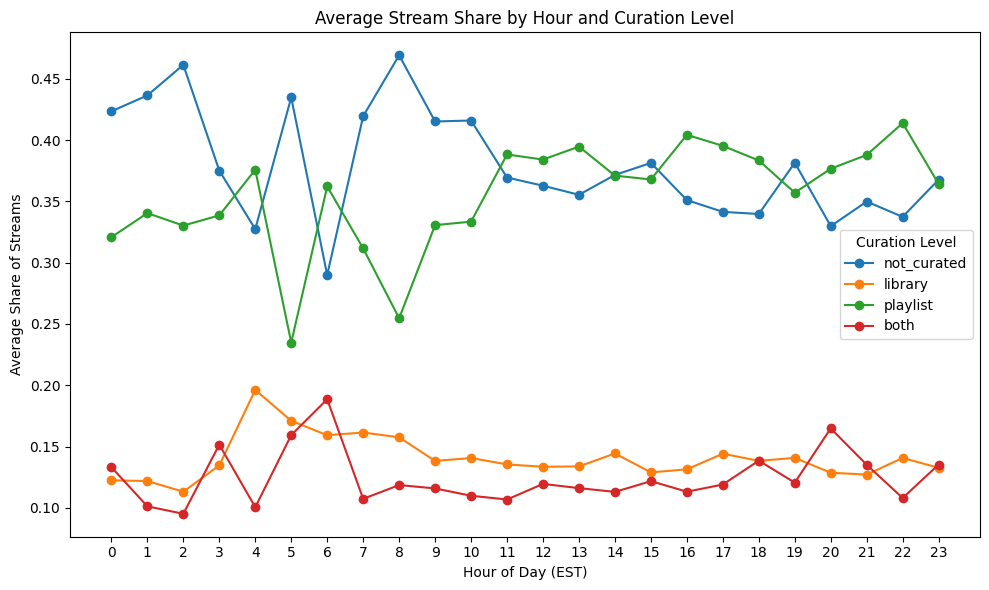

In [16]:
# Visual 1: Hourly average stream share by curation label

plt.figure(figsize=(10, 6))

for label in curation_order:
    temp = avg_user_hour_curation[avg_user_hour_curation["curation_label"] == label]
    plt.plot(temp["hour_est"], temp["avg_stream_share"], marker="o", label=label)

plt.title("Average Stream Share by Hour and Curation Level")
plt.xlabel("Hour of Day (EST)")
plt.ylabel("Average Share of Streams")
plt.xticks(range(0, 24))
plt.legend(title="Curation Level")
plt.tight_layout()
plt.show()

#### Visual 2
Hourly average minutes share by curation label

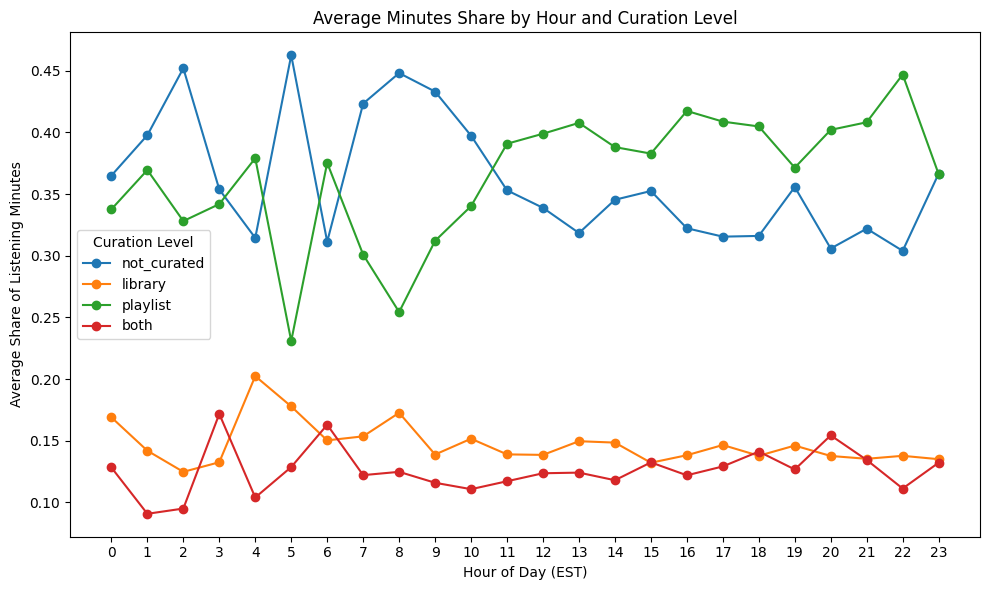

In [ ]:
# Visual 2:Hourly average minutes share by curation label

plt.figure(figsize=(10, 6))

for label in curation_order:
    temp = avg_user_hour_curation[avg_user_hour_curation["curation_label"] == label]
    plt.plot(temp["hour_est"], temp["avg_minutes_share"], marker="o", label=label)

plt.title("Average Minutes Share by Hour and Curation Level")
plt.xlabel("Hour of Day (EST)")
plt.ylabel("Average Share of Listening Minutes")
plt.xticks(range(0, 24))
plt.legend(title="Curation Level")
plt.tight_layout()
plt.show()

#### Visual 3
Day-of-week average stream share by curation label 

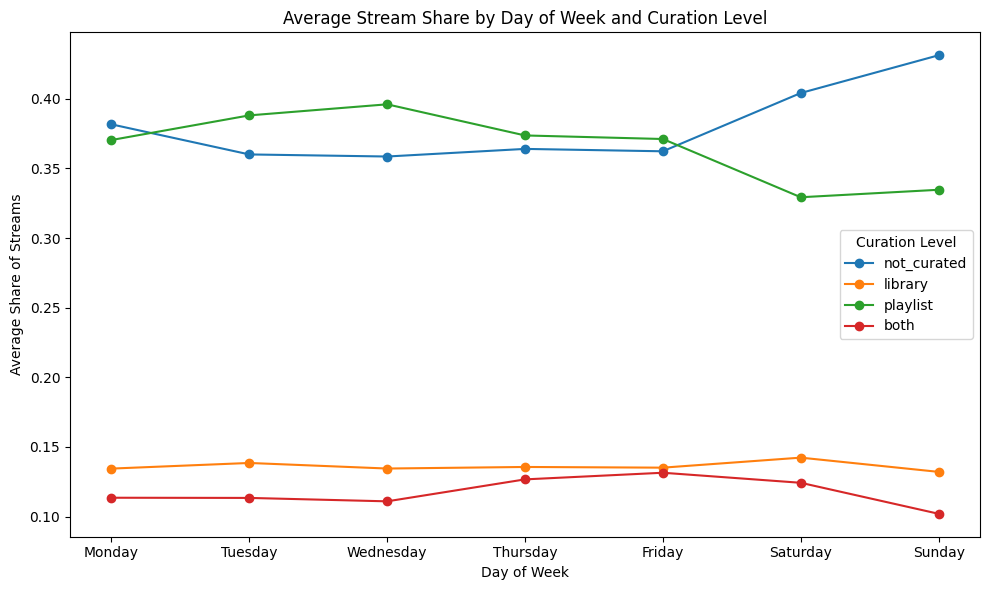

In [18]:
# Visual 3: Day-of-week average stream share by curation label

plt.figure(figsize=(10, 6))

for label in curation_order:
    temp = avg_user_day_curation[avg_user_day_curation["curation_label"] == label]
    plt.plot(temp["day_of_week_est"], temp["avg_stream_share"], marker="o", label=label)

plt.title("Average Stream Share by Day of Week and Curation Level")
plt.xlabel("Day of Week")
plt.ylabel("Average Share of Streams")
plt.legend(title="Curation Level")
plt.tight_layout()
plt.show()

#### Visual 4
Day-of-week average minutes share by curation label

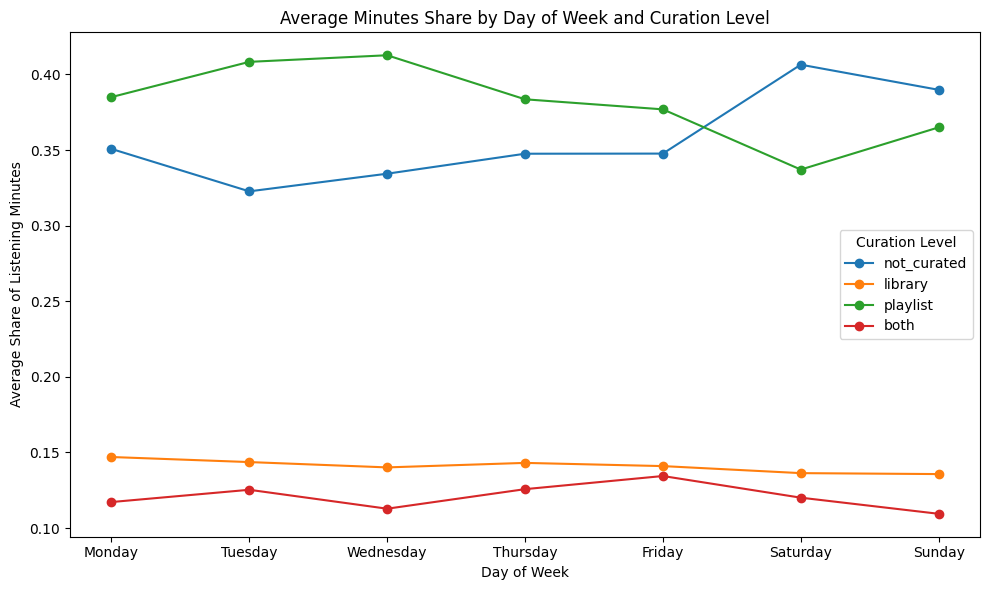

In [19]:
# Visual 4: Day-of-week average minutes share by curation label

plt.figure(figsize=(10, 6))

for label in curation_order:
    temp = avg_user_day_curation[avg_user_day_curation["curation_label"] == label]
    plt.plot(temp["day_of_week_est"], temp["avg_minutes_share"], marker="o", label=label)

plt.title("Average Minutes Share by Day of Week and Curation Level")
plt.xlabel("Day of Week")
plt.ylabel("Average Share of Listening Minutes")
plt.legend(title="Curation Level")
plt.tight_layout()
plt.show()

### Optional Visuals
Bar chart(instead of line)

#### Visual 3.2
Stream share grouped bars 

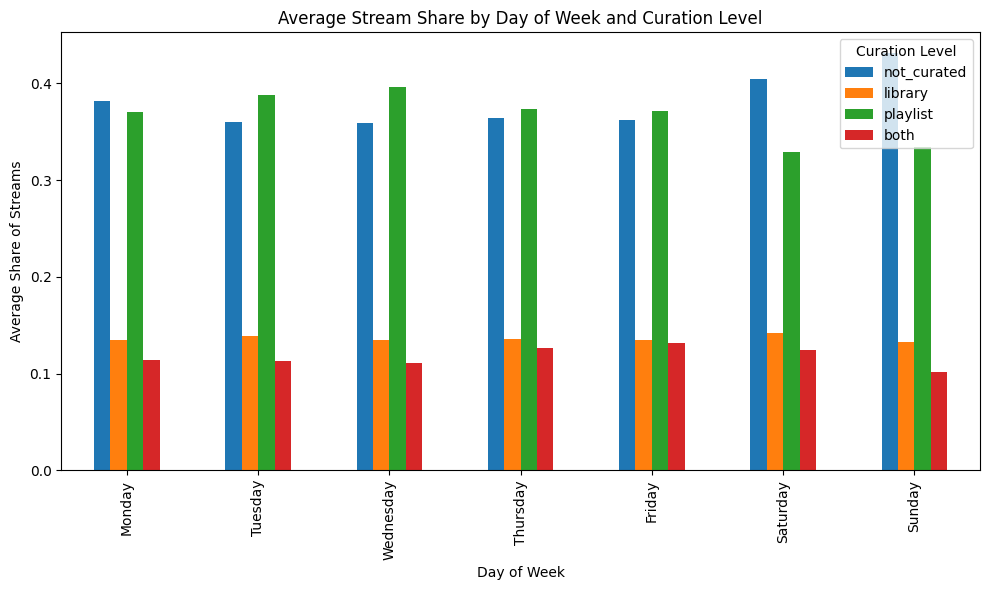

In [20]:
weekday_stream_pivot = avg_user_day_curation.pivot(
    index="day_of_week_est",
    columns="curation_label",
    values="avg_stream_share"
)

weekday_stream_pivot = weekday_stream_pivot[curation_order]

weekday_stream_pivot.plot(kind="bar", figsize=(10, 6))
plt.title("Average Stream Share by Day of Week and Curation Level")
plt.xlabel("Day of Week")
plt.ylabel("Average Share of Streams")
plt.legend(title="Curation Level")
plt.tight_layout()
plt.show()

#### Visual 4.2
Minutes share grouped bars

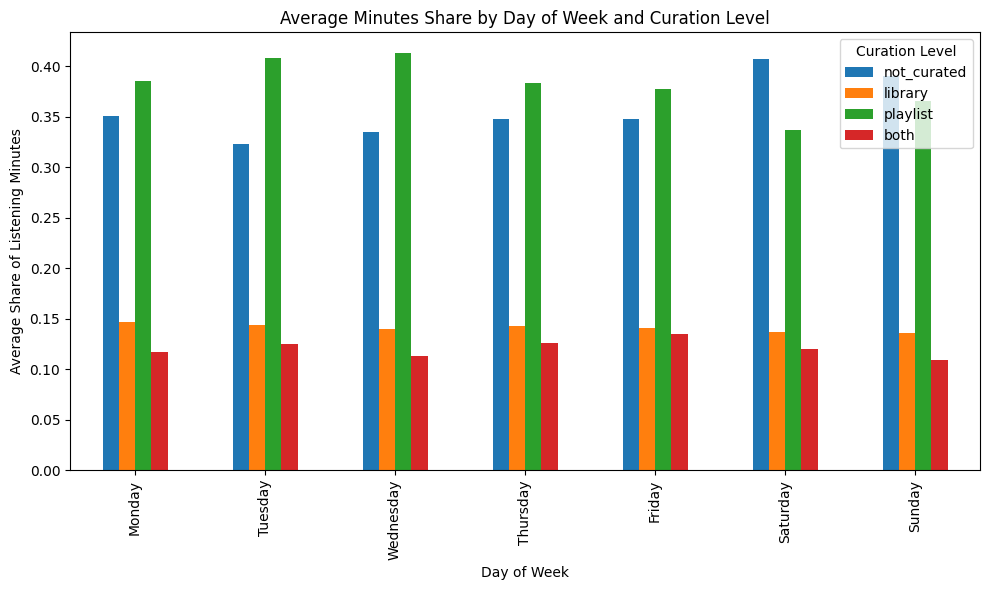

In [21]:
weekday_minutes_pivot = avg_user_day_curation.pivot(
    index="day_of_week_est",
    columns="curation_label",
    values="avg_minutes_share"
)

weekday_minutes_pivot = weekday_minutes_pivot[curation_order]

weekday_minutes_pivot.plot(kind="bar", figsize=(10, 6))
plt.title("Average Minutes Share by Day of Week and Curation Level")
plt.xlabel("Day of Week")
plt.ylabel("Average Share of Listening Minutes")
plt.legend(title="Curation Level")
plt.tight_layout()
plt.show()

## Insights
1. **Time of day** appears to be a **stronger** behavioral signal than day of week for curated vs non-curated listening.
- The hourly charts show much more movement than the weekday charts
2. Not-curated content is stronger in the late night / early morning
- From roughly 12 AM to about 10 AM, not_curated is often the largest share, especially in both: average stream share & average minutes share
3. Playlist-curated content becomes stronger later in the day
- From around 11 AM onward, playlist generally rises and often overtakes not_curated, especially through the afternoon and evening.
- **playlist-curated** content --> **later** in the day (after 11 am, afternoon)
- **not-curated** content --> more dominant **earlier** in the day (00:00-10:00)
4. Library is relatively stable and secondary
- library stays fairly flat across both hour and weekday charts, usually around a smaller middle share. It matters, but it does not appear to drive the main behavioral shifts.
5. **Day-of-week differences are present but smaller; playlist-curated listening is somewhat stronger on weekdays, while not-curated listening is relatively more prominent on weekends.**
- Not curated > Playlist only on weekends (why? What caused the shift, what user behavior)
    - weekend: not curated > playlist
    - weekday: playlist > not curated
- -->
    - **weekday** listening may be a bit more **playlist-structured**
    - **weekend** listening may be a bit more **spontaneous or less intentionally** curated